# Parquet 파일 구성 확인

SO100 VR 텔레옵 데이터셋의 parquet 파일 구조와 내용을 분석합니다.


In [23]:
# 라이브러리 로드
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import yaml
import json
from typing import Dict, List
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("✅ 필수 라이브러리 로드 완료")

✅ 필수 라이브러리 로드 완료


In [25]:
# Config 로드 및 데이터셋 경로 설정
config_path = Path("/home/choyunsang/lerobot/config.yaml")
chunk_num = 000
file_num = 0

try:
    with open(config_path) as f:
        config = yaml.safe_load(f)
    dataset_root = Path(config["dataset"]["root"])
    repo_id = config["dataset"]["repo_id"]
    task_name = config["dataset"]["task_name"]
    print(f"✅ Config 로드 완료")
    print(f"   - Dataset root: {dataset_root}")
    print(f"   - Repo ID: {repo_id}")
    print(f"   - Task Name: {task_name}")
except Exception as e:
    # Fallback 기본값
    dataset_root = Path.home() / "Dataset"
    repo_id = "so100_vr_record"
    print(f"⚠️  Config 로드 실패, 기본값 사용: {e}")
    print(f"   - Dataset root: {dataset_root}")
    print(f"   - Repo ID: {repo_id}")
    print(f"   - Task Name: {task_name}")

# 데이터셋 경로
dataset_path = dataset_root.joinpath(task_name)
chunk_path = dataset_path.joinpath("data", f"chunk-{chunk_num:03d}")

print(f"\n📁 데이터셋 경로: {dataset_path}")
print(f"📁 Chunk 경로: {chunk_path}")
print(f"   - 존재 여부: {chunk_path.exists()}")

✅ Config 로드 완료
   - Dataset root: /home/choyunsang/Dataset
   - Repo ID: ranggae/so100_vr_record
   - Task Name: SO100_VR_teleoperation

📁 데이터셋 경로: /home/choyunsang/Dataset/SO100_VR_teleoperation
📁 Chunk 경로: /home/choyunsang/Dataset/SO100_VR_teleoperation/data/chunk-000
   - 존재 여부: True


In [26]:
# parquet 파일 읽기
df = pd.read_parquet(chunk_path / f"file-{file_num:03d}.parquet")
print(df.head())

                                              action  \
0  [-3.3186812, -0.08791209, 3.5604396, 0.6813187...   
1  [-3.3186812, -0.08791209, 3.5604396, 0.6813187...   
2  [-3.3186812, -0.043956045, 3.5604396, 0.681318...   
3  [-3.010989, 0.13186814, 3.5164835, 0.6813187, ...   
4  [-2.6593406, 0.21978022, 3.5164835, 0.6813187,...   

                                   observation.state  \
0  [-6.6373625, -0.17582418, 7.120879, 1.3626374,...   
1  [-6.6373625, -0.17582418, 7.120879, 1.3626374,...   
2  [-6.6373625, -0.08791209, 7.120879, 1.3626374,...   
3  [-6.021978, 0.26373628, 7.032967, 1.3626374, -...   
4  [-5.4065933, 0.43956044, 7.032967, 1.3626374, ...   

                            observation.images.right  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\r

In [27]:
# 메타데이터 확인
metadata_path = dataset_path / "meta" / "info.json"

print("=" * 70)
print("📋 데이터셋 메타데이터")
print("=" * 70)

if metadata_path.exists():
    with open(metadata_path) as f:
        metadata = json.load(f)
    
    print(f"\n✅ Metadata 파일 발견: {metadata_path}")
    print(f"\n주요 정보:")
    print(f"  - repo_id: {metadata.get('repo_id', 'N/A')}")
    print(f"  - fps: {metadata.get('fps', 'N/A')}")
    print(f"  - robot_type: {metadata.get('robot_type', 'N/A')}")
    print(f"  - total_episodes: {metadata.get('total_episodes', 'N/A')}")
    print(f"  - total_frames: {metadata.get('total_frames', 'N/A')}")
    print(f"  - video_extension: {metadata.get('video_extension', 'N/A')}")
    print(f"  - use_videos: {metadata.get('use_videos', 'N/A')}")
    
    print(f"\n특성 정보 (Features):")
    if "features" in metadata:
        for feature_name, feature_info in metadata["features"].items():
            print(f"  - {feature_name}: {feature_info}")
else:
    print(f"⚠️  Metadata 파일을 찾을 수 없습니다: {metadata_path}")

📋 데이터셋 메타데이터

✅ Metadata 파일 발견: /home/choyunsang/Dataset/SO100_VR_teleoperation/meta/info.json

주요 정보:
  - repo_id: N/A
  - fps: 10
  - robot_type: so_follower
  - total_episodes: 1
  - total_frames: 237
  - video_extension: N/A
  - use_videos: N/A

특성 정보 (Features):
  - action: {'dtype': 'float32', 'shape': [6], 'names': ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']}
  - observation.state: {'dtype': 'float32', 'shape': [6], 'names': ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']}
  - observation.images.right: {'dtype': 'image', 'shape': [3, 480, 640], 'names': ['channel', 'height', 'width']}
  - observation.images.head: {'dtype': 'image', 'shape': [3, 480, 640], 'names': ['channel', 'height', 'width']}
  - timestamp: {'dtype': 'float32', 'shape': [1], 'names': None}
  - frame_index: {'dtype': 'int64', 'shape': [1], 'names': None}
  - episode_index: {'dtype':


📊 데이터 샘플 로드
file-000.parquet 파일에서 데이터 샘플을 로드하여 시각화합니다...


<Figure size 1000x600 with 0 Axes>

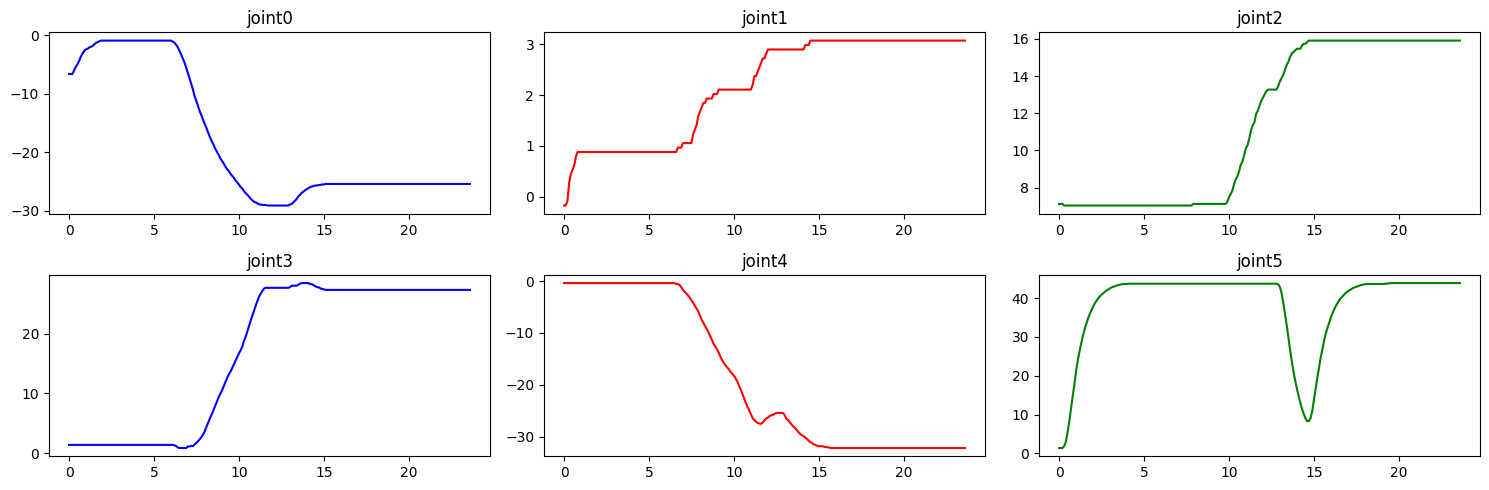

In [ ]:
# 데이터 샘플 로드 및 확인 - Timestep vs Observation/Action
import matplotlib.pyplot as plt
import numpy as np

file_num = 0
df = pd.read_parquet(chunk_path / f"file-{file_num:03d}.parquet")

print("\n" + "=" * 70)
print("📊 데이터 샘플 로드")
print("=" * 70)
    
try:   
    # Observation과 Action 함께 시각화

    print(f"file-{file_num:03d}.parquet 파일에서 데이터 샘플을 로드하여 시각화합니다...")

    plt.figure(figsize=(10, 6)) # 그래프 크기 설정

    # 'x_column'과 'y_column'에 본인의 데이터 열 이름을 입력하세요.
    timestamp = df['timestamp']

    observation_state = df['observation.state']
    action = df['action']
    joint0 = [row[0] for row in observation_state]
    joint1 = [row[1] for row in observation_state]
    joint2 = [row[2] for row in observation_state]
    joint3 = [row[3] for row in observation_state]
    joint4 = [row[4] for row in observation_state]
    joint5 = [row[5] for row in observation_state]

    action_joint0 = [row[0] for row in action]
    action_joint1 = [row[1] for row in action]
    action_joint2 = [row[2] for row in action]
    action_joint3 = [row[3] for row in action]
    action_joint4 = [row[4] for row in action]
    action_joint5 = [row[5] for row in action]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 5))


    axes[0][0].plot(timestamp, joint0, 'b')
    axes[0][0].plot(timestamp, action_joint0, 'r--')
    axes[0][0].set_title('joint0')

    axes[0][1].plot(timestamp, joint1, 'r')
    axes[0][1].plot(timestamp, action_joint1, 'r--')
    axes[0][1].set_title('joint1')

    axes[0][2].plot(timestamp, joint2, 'g')
    axes[0][2].plot(timestamp, action_joint2, 'r--')
    axes[0][2].set_title('joint2')

    axes[1][0].plot(timestamp, joint3, 'b')
    axes[1][0].plot(timestamp, action_joint3, 'r--')
    axes[1][0].set_title('joint3')

    axes[1][1].plot(timestamp, joint4, 'r')
    axes[1][1].plot(timestamp, action_joint4, 'r--')
    axes[1][1].set_title('joint4')

    axes[1][2].plot(timestamp, joint5, 'g')
    axes[1][2].plot(timestamp, action_joint5, 'r--')
    axes[1][2].set_title('joint5')

    plt.tight_layout() # 그래프 간격 자동 조정
    plt.show()
    
except Exception as e:
    print(f"⚠️  데이터 로드 중 오류: {e}")

In [21]:
# 파일의 첫 번째 행에서 이미지 데이터 가져오기
file_num = 0    # 파일 번호
image_idx = 0   # 0: right, 1: head
frame_idx = 0    # 프레임 인덱스


🖼️  Parquet 파일에서 이미지 읽기

📷 발견된 이미지 컬럼: ['observation.images.right', 'observation.images.head']

✅ 선택된 컬럼: observation.images.right
   데이터 타입: <class 'dict'>
   딕셔너리 키: ['bytes', 'path']

   딕셔너리 내용 (타입):
     - bytes: bytes (306401 bytes)
     - path: str = frame-000000.png

✅ Bytes 데이터 발견: 'bytes' (306401 bytes)
   이미지 크기: (640, 480)
   이미지 모드: RGB


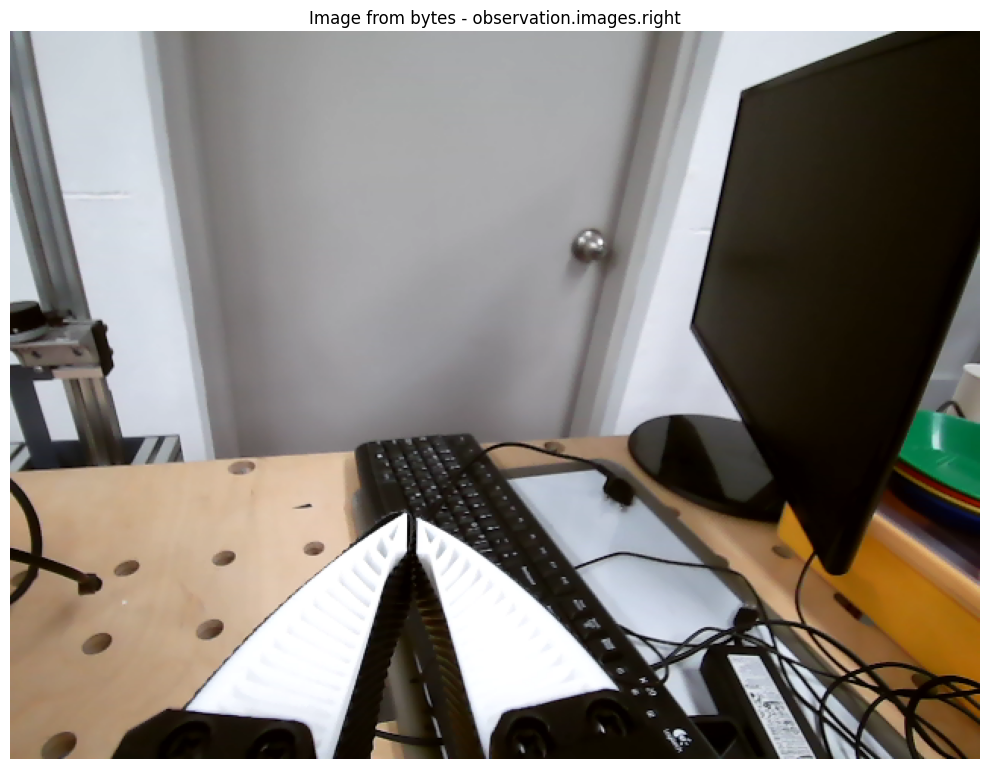


✅ 이미지 출력 완료!


In [22]:
# 이미지 확인
from PIL import Image
import io
import cv2

df = pd.read_parquet(chunk_path / f"file-{file_num:03d}.parquet")

print("\n" + "=" * 70)
print("🖼️  Parquet 파일에서 이미지 읽기")
print("=" * 70)

# 이미지 관련 컬럼 찾기
image_columns = [col for col in df.columns if 'image' in col.lower()]
print(f"\n📷 발견된 이미지 컬럼: {image_columns}")

if image_columns:
    # 첫 번째 이미지 컬럼에서 첫 번째 프레임의 이미지 가져오기
    first_image_col = image_columns[image_idx]
    first_image_data = df[first_image_col].iloc[frame_idx]
    
    print(f"\n✅ 선택된 컬럼: {first_image_col}")
    print(f"   데이터 타입: {type(first_image_data)}")
    
    # 딕셔너리 구조 확인
    if isinstance(first_image_data, dict):
        print(f"   딕셔너리 키: {list(first_image_data.keys())}")
        print(f"\n   딕셔너리 내용 (타입):")
        for key, value in first_image_data.items():
            if isinstance(value, bytes):
                print(f"     - {key}: bytes ({len(value)} bytes)")
            else:
                print(f"     - {key}: {type(value).__name__} = {value}")
        
        try:
            # bytes 데이터 찾기
            image_bytes = None
            bytes_key = None
            
            for key, value in first_image_data.items():
                if isinstance(value, bytes):
                    image_bytes = value
                    bytes_key = key
                    break
            
            if image_bytes:
                print(f"\n✅ Bytes 데이터 발견: '{bytes_key}' ({len(image_bytes)} bytes)")
                
                # bytes를 PIL Image로 변환
                image = Image.open(io.BytesIO(image_bytes))
                
                print(f"   이미지 크기: {image.size}")
                print(f"   이미지 모드: {image.mode}")
                
                # 이미지 표시
                plt.figure(figsize=(10, 8))
                plt.imshow(image)
                plt.title(f"Image from {bytes_key} - {first_image_col}")
                plt.axis('off')
                plt.tight_layout()
                plt.show()
                
                print(f"\n✅ 이미지 출력 완료!")
            else:
                # bytes가 없으면 비디오 파일에서 추출
                print(f"\n📹 Bytes 데이터가 없어, 비디오 파일에서 추출 시도...")
                
                video_path = None
                frame_index = 0
                
                if 'path' in first_image_data:
                    video_path = first_image_data['path']
                    frame_index = first_image_data.get('frame_index', 0)
                elif 'video_path' in first_image_data:
                    video_path = first_image_data['video_path']
                    frame_index = first_image_data.get('frame_index', 0)
                
                if video_path:
                    print(f"   비디오 파일: {video_path}")
                    print(f"   프레임 인덱스: {frame_index}")
                    
                    # 비디오 파일 경로 구성
                    video_file = dataset_path / "videos" / video_path
                    
                    if video_file.exists():
                        print(f"   파일 존재: ✅")
                        
                        # OpenCV로 비디오 프레임 추출
                        cap = cv2.VideoCapture(str(video_file))
                        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
                        ret, frame = cap.read()
                        cap.release()
                        
                        if ret:
                            # BGR을 RGB로 변환
                            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                            
                            print(f"   이미지 크기: {image.shape}")
                            
                            # 이미지 표시
                            plt.figure(figsize=(10, 8))
                            plt.imshow(image)
                            plt.title(f"Frame {frame_index} - {first_image_col}")
                            plt.axis('off')
                            plt.tight_layout()
                            plt.show()
                            
                            print(f"✅ 이미지 출력 완료!")
                        else:
                            print(f"⚠️  프레임 추출 실패")
                    else:
                        print(f"   파일 경로: {video_file}")
                        print(f"   파일 존재: ❌")
                else:
                    print(f"⚠️  비디오 경로 정보를 찾을 수 없습니다.")
                
        except Exception as e:
            print(f"⚠️  이미지 처리 중 오류: {e}")
            import traceback
            traceback.print_exc()
    else:
        print(f"   데이터 타입: {type(first_image_data).__name__}")
        print("⚠️  딕셔너리가 아닌 다른 형식입니다.")
else:
    print("⚠️  이미지 컬럼을 찾을 수 없습니다.")